     Function Transformer

In [57]:
import pandas as pd
import numpy as np
import scipy.stats as stats #use for qqplot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline

In [4]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isna().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [9]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

In [10]:
df.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [11]:
df.sample(5)

,Survived,Age,Fare
463,0,48.000000,13.000
613,0,29.699118,7.750
107,1,29.699118,7.775
682,0,20.000000,9.225
327,1,36.000000,13.000


In [13]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,
                                               random_state=42)

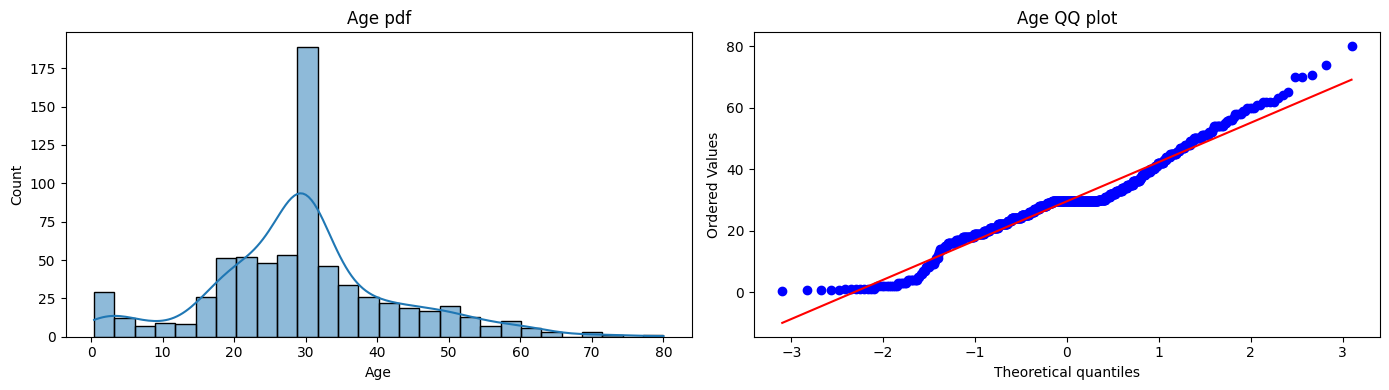

In [28]:
plt.figure(figsize=(14, 4))

# First subplot (Age pdf)
plt.subplot(121)  # (1 row, 2 columns, first subplot)
sns.histplot(x_train['Age'], kde=True)  # Use histplot instead of displot
plt.title('Age pdf')

# Second subplot (Age QQ plot)
plt.subplot(122)  # (1 row, 2 columns, second subplot)
stats.probplot(x_train['Age'], dist='norm', plot=plt)  # QQ plot with scipy.stats
plt.title('Age QQ plot')

# Show the plots
plt.tight_layout()  # Adjust subplots to prevent overlap
plt.show()

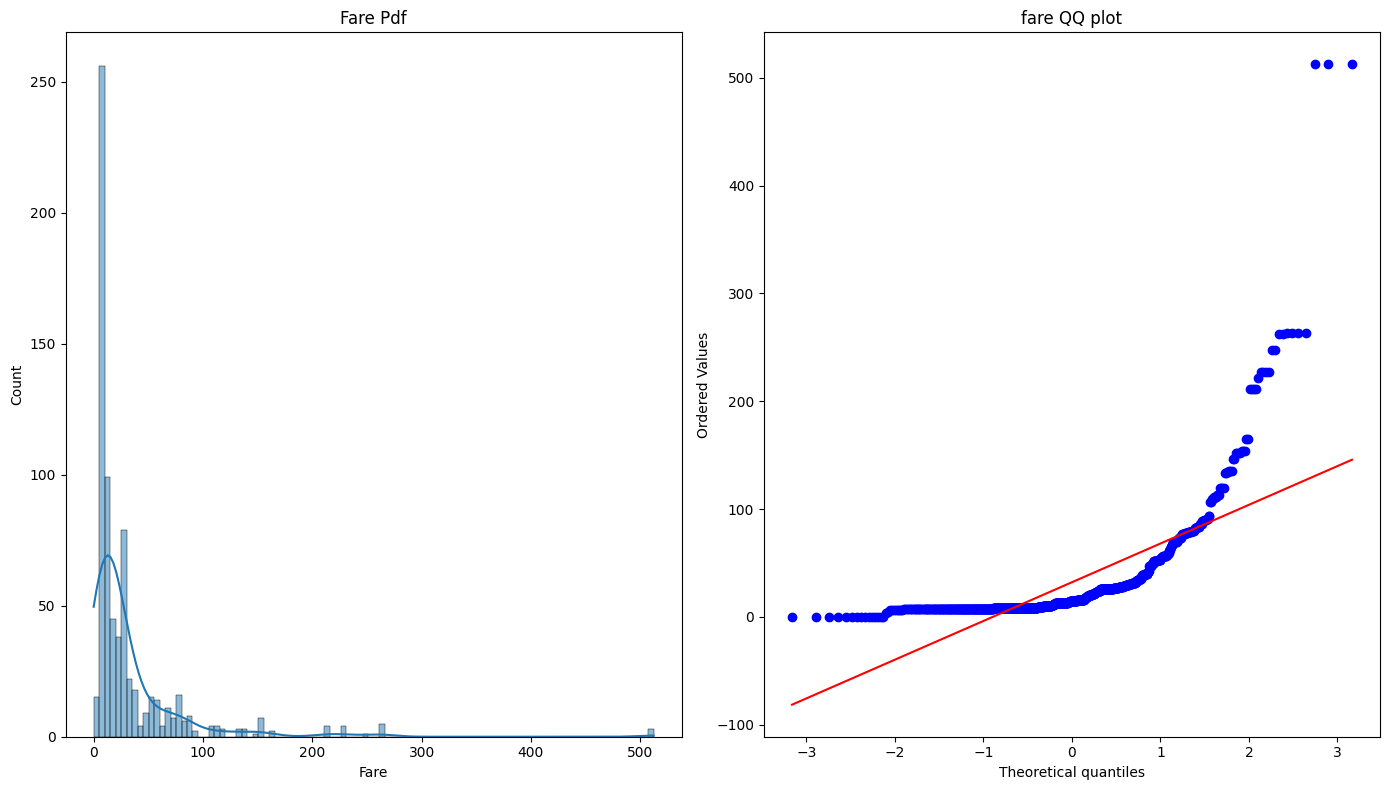

In [38]:
plt.figure(figsize=(14,8))
plt.subplot(121)
sns.histplot(x_train['Fare'],kde=True)
plt.title('Fare Pdf')

plt.subplot(122)
stats.probplot(df['Fare'],dist='norm',plot=plt)
plt.title('fare QQ plot')
plt.tight_layout()
plt.show()

In [39]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [42]:
clf.fit(x_train,y_train)

LogisticRegression()

In [43]:
clf2.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

In [47]:
print("Accuracy of LR:",accuracy_score(y_test,y_pred))
print("Accuracu of DT:",accuracy_score(y_test,y_pred1))

Accuracy of LR: 0.6480446927374302
Accuracu of DT: 0.6815642458100558


Function transformer

In [49]:
trf=FunctionTransformer(func=np.log1p)

In [51]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [54]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)
y_pred=clf.predict(x_test_transformed)
y_pred1=clf2.predict(x_test_transformed)

print("Accuracy Of LR:",accuracy_score(y_test,y_pred))
print("Accuracy of DT:",accuracy_score(y_test,y_pred1))

Accuracy Of LR: 0.6815642458100558
Accuracy of DT: 0.6703910614525139


In [67]:
from sklearn.model_selection import cross_val_score

In [58]:
x_transformed=trf.fit_transform(x)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print("LR:",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
print("DT:",np.mean(cross_val_score(clf2,x_transformed,y,scoring='accuracy',cv=10)))

LR: 0.678027465667915
DT: 0.6532209737827717


Text(0.5, 1.0, 'Fare after log')

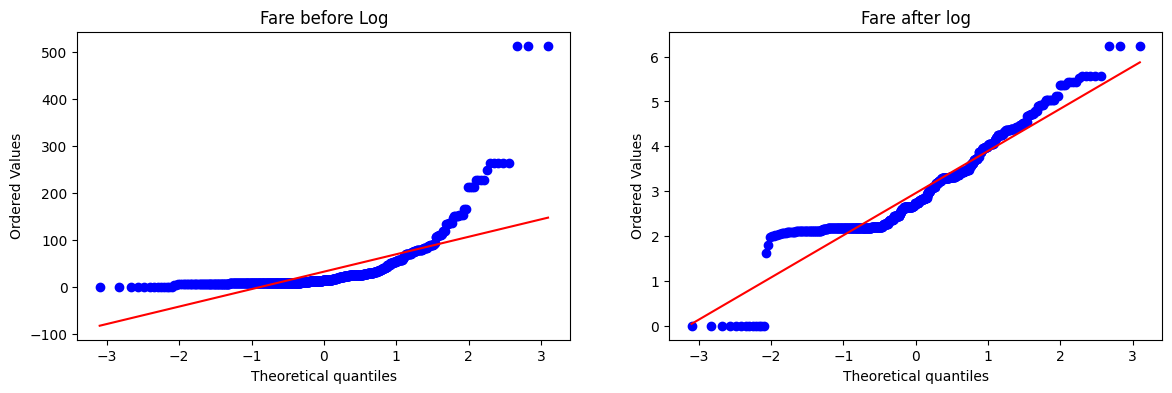

In [64]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title("Fare before Log")

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'],dist="norm",plot=plt)
plt.title("Fare after log")

Text(0.5, 1.0, 'Age after log')

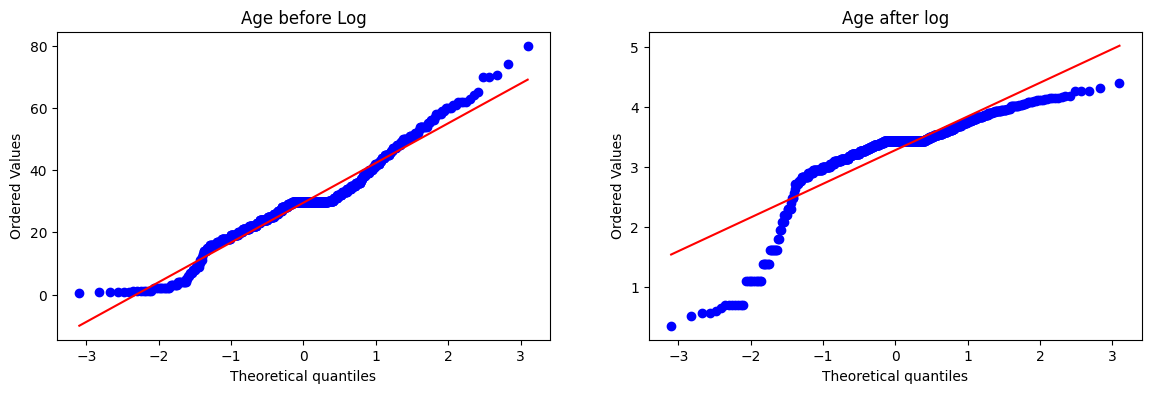

In [66]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title("Age before Log")

plt.subplot(122)
stats.probplot(x_train_transformed['Age'],dist="norm",plot=plt)
plt.title("Age after log")

In [72]:
trf2=ColumnTransformer([
    ('log',FunctionTransformer(np.log1p),['Fare'])
],remainder='passthrough')
x_train_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)

In [82]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)

DecisionTreeClassifier()

In [83]:
y_pred=clf.predict(x_test_transformed2)
y_pred2=clf2.predict(x_test_transformed2)

In [84]:
print("Accuracy OF LR:",accuracy_score(y_test,y_pred))
print("Accuracy OF DT:",accuracy_score(y_test,y_pred2))

Accuracy OF LR: 0.6703910614525139
Accuracy OF DT: 0.6927374301675978
